## 1. Import Libraries

In [5]:
import sys
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Video, display
from tqdm.notebook import tqdm

# Import custom modules
from golf_pipeline.video_io import extract_frames_from_video
from golf_pipeline.preprocessing import StylePreprocessor
from golf_pipeline.keypoints import GolferDetector, SkeletonDetector

# Setup matplotlib
%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 10)

print("✓ All libraries imported successfully")

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All libraries imported successfully


## 2. Configuration

In [13]:
# ==================== CONFIGURATION ====================
# Input video path
VIDEO_INPUT = r"augmented_dataset\Trong nhà - Indoor\Band 1-2\Side-6020-7_no00.mp4"

# Output directory
OUTPUT_DIR = Path("pipeline_output")
OUTPUT_DIR.mkdir(exist_ok=True)

# Preprocessing configuration
PREPROCESSING_CONFIG = {
    "use_adaptive": False,
    "apply_sharpening": True,
    "sharpen_strength": 0.8,
    "apply_edge_enhancement": True,
    "edge_alpha": 0.3,
    "apply_denoise": True,
    "gamma": 1.0,
    "contrast_alpha": 1.1,
    "contrast_beta": 5.0,
}

# Detection configuration
DETECTION_CONFIG = {
    "conf_threshold": 0.25,
    "use_coco_format": True,  # False = 33 keypoints (MediaPipe full)
}

# Video processing
FRAME_SKIP = 1  # Process every frame
MAX_FRAMES = None  # None = process entire video

print(f"Input video: {VIDEO_INPUT}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Keypoint format: {'COCO (17)' if DETECTION_CONFIG['use_coco_format'] else 'MediaPipe (33)'}")

Input video: augmented_dataset\Trong nhà - Indoor\Band 1-2\Side-6020-7_no00.mp4
Output directory: pipeline_output
Keypoint format: COCO (17)


## 3. Load Video

Loading video...
✓ Loaded 342 frames
✓ FPS: 30.0
✓ Frame size: 720x1280
✓ Duration: 11.40 seconds


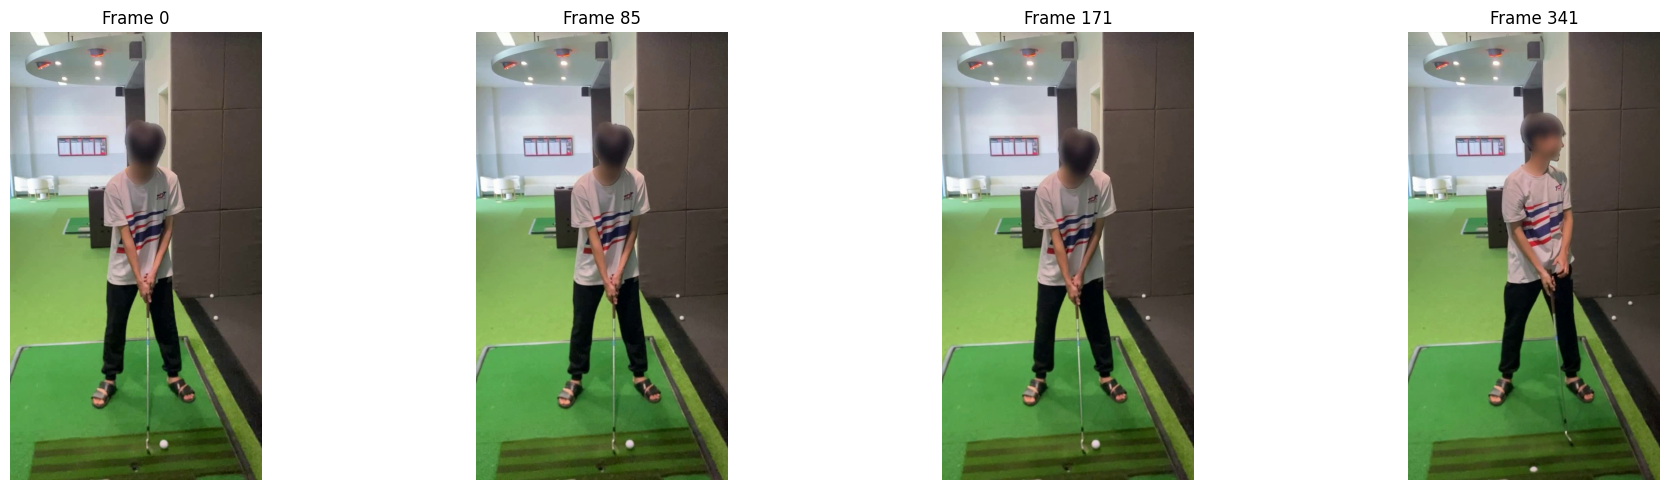

In [14]:
print("Loading video...")
frames, fps = extract_frames_from_video(
    VIDEO_INPUT, 
    sample_every=FRAME_SKIP,
    max_frames=MAX_FRAMES
)

print(f"✓ Loaded {len(frames)} frames")
print(f"✓ FPS: {fps}")
print(f"✓ Frame size: {frames[0].shape[1]}x{frames[0].shape[0]}")
print(f"✓ Duration: {len(frames)/fps:.2f} seconds")

# Display sample frames
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
sample_indices = [0, len(frames)//4, len(frames)//2, len(frames)-1]
for ax, idx in zip(axes, sample_indices):
    ax.imshow(cv2.cvtColor(frames[idx], cv2.COLOR_BGR2RGB))
    ax.set_title(f"Frame {idx}")
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Preprocessing

### 4.1. Analyze Image Properties

In [15]:
# Initialize preprocessor
preprocessor = StylePreprocessor(reference_image=frames[0])

# Analyze sample frame
sample_frame = frames[len(frames)//2]
props = preprocessor.analyze_image_properties(sample_frame)

print("\n========== IMAGE PROPERTIES ANALYSIS ==========")
print(f"Brightness:  {props['brightness']:.1f} / 255")
print(f"Contrast:    {props['contrast']:.1f} / 255")
print(f"Noise Level: {props['noise_level']:.1f} / 100")
print(f"Sharpness:   {props['sharpness']:.1f} / 100")
print("===============================================\n")


========== IMAGE PROPERTIES ANALYSIS ==========
Brightness:  110.7 / 255
Contrast:    54.6 / 255
Noise Level: 3.4 / 100
Sharpness:   18.6 / 100



### 4.2. Preview Preprocessing Steps

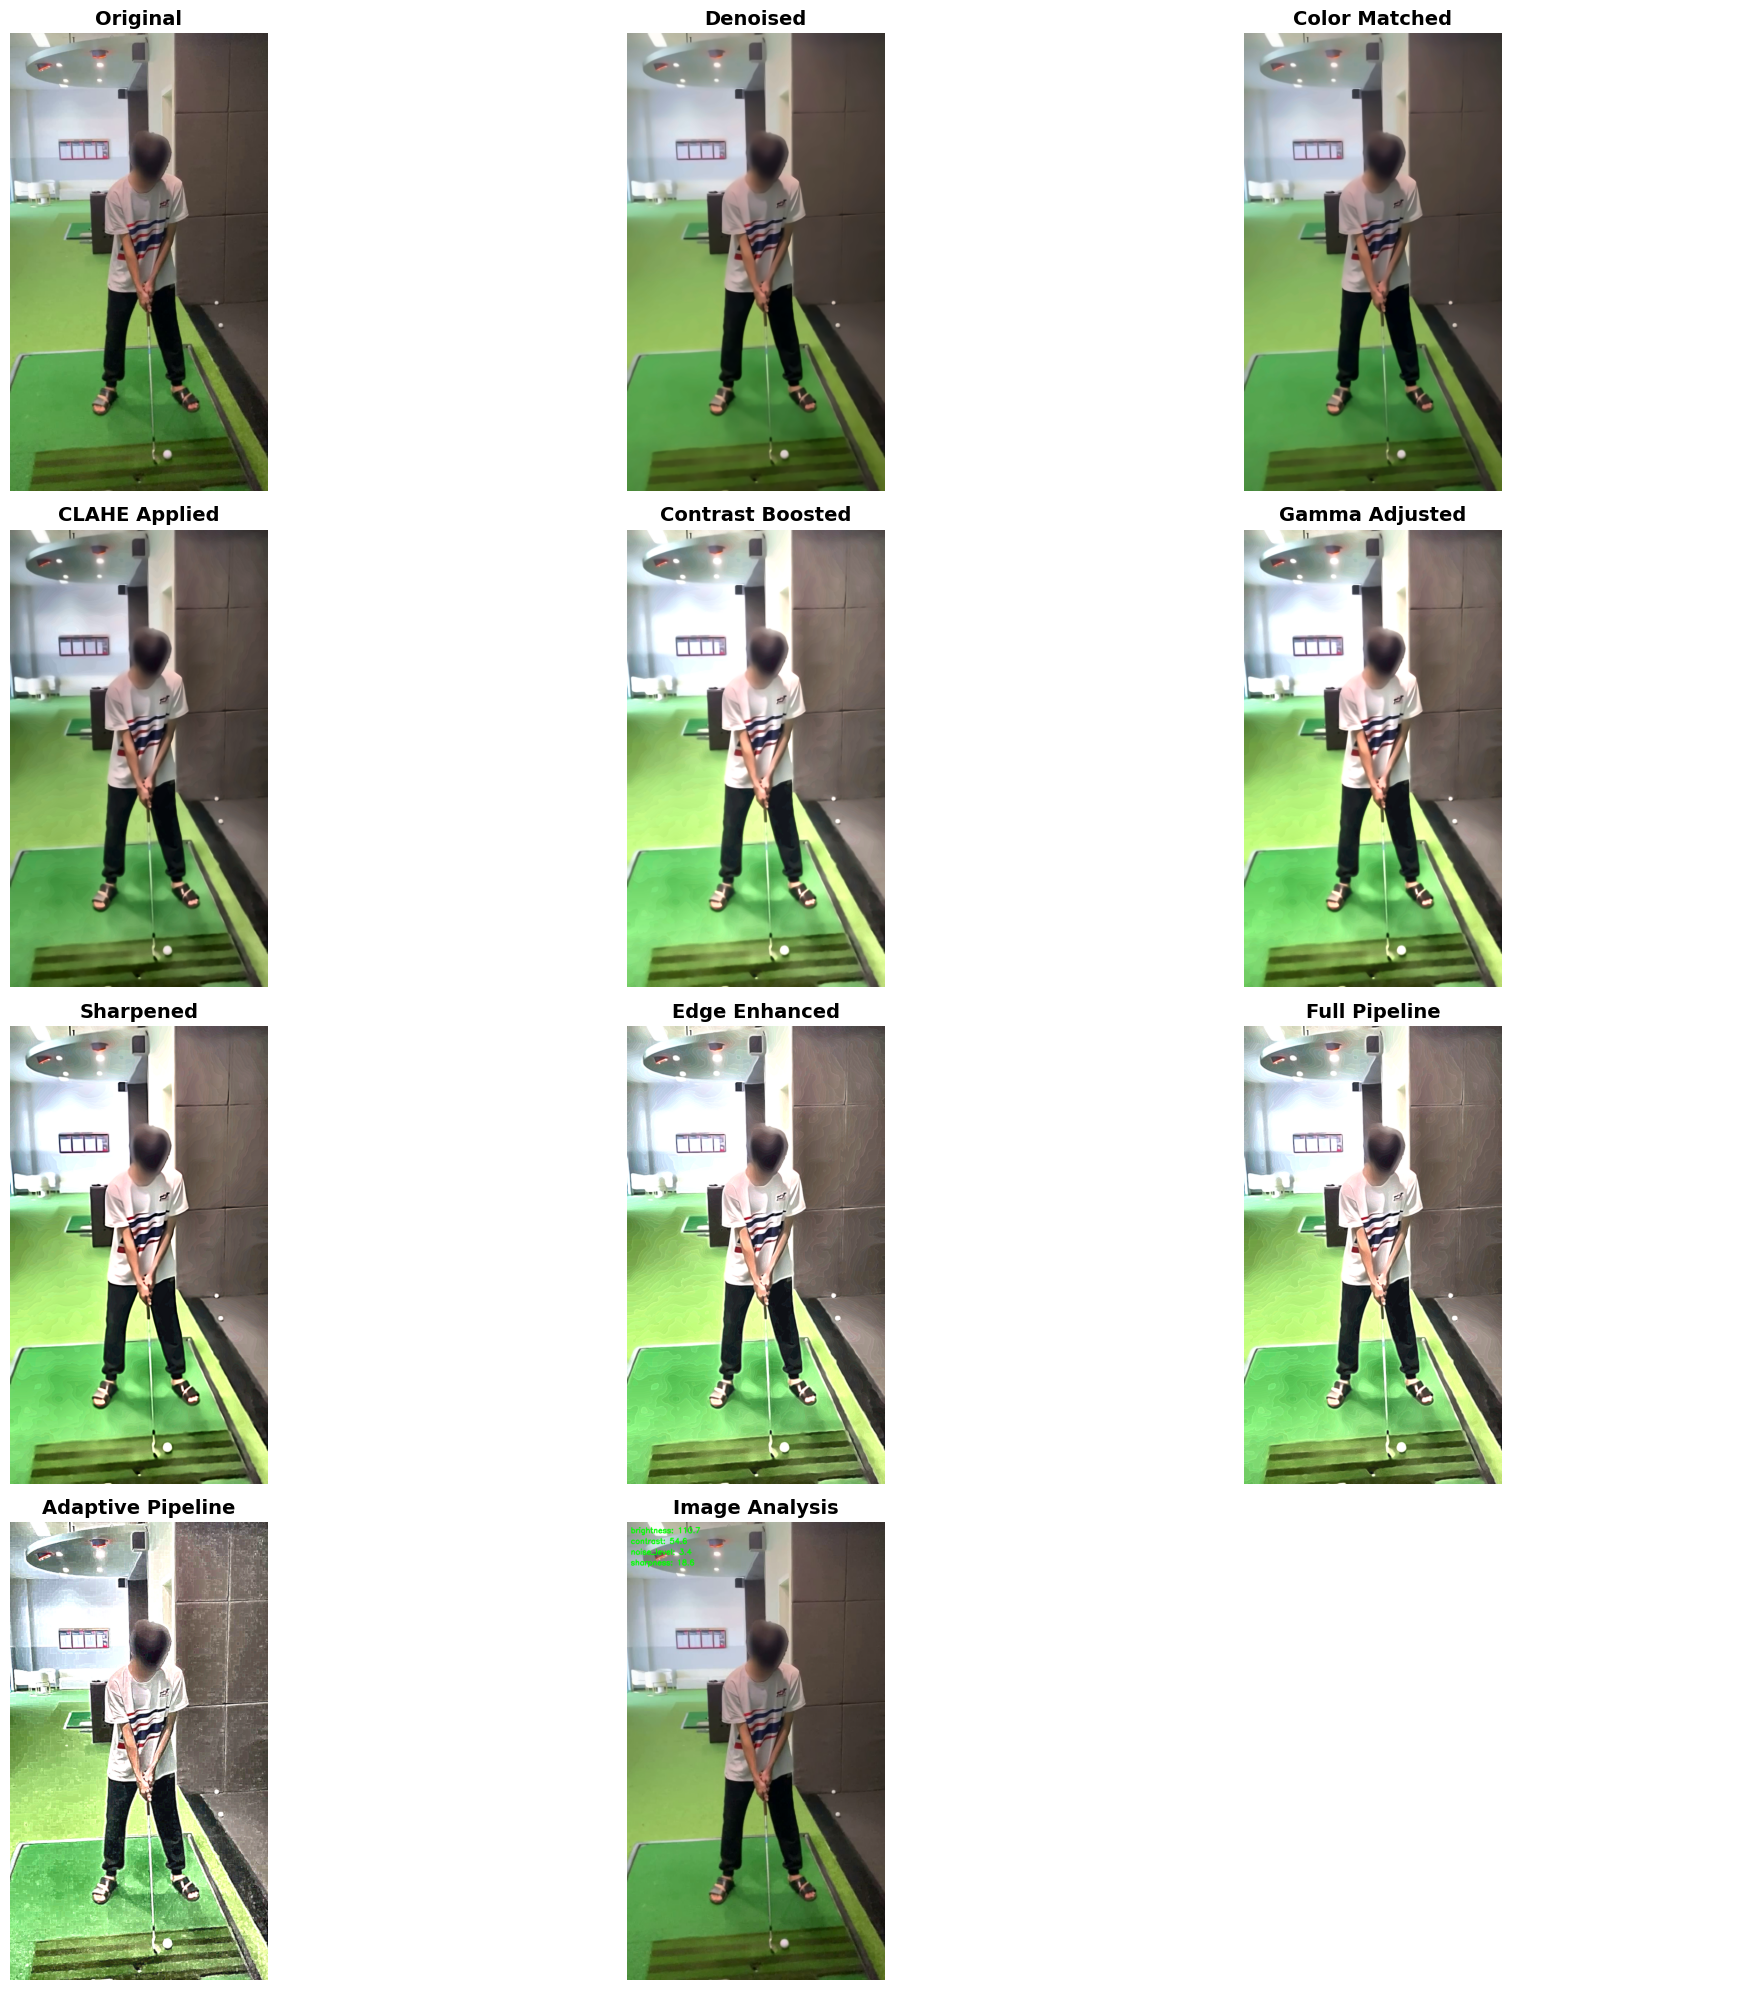


✓ Preprocessing steps visualization complete


In [16]:
# Visualize all preprocessing steps
preprocessing_steps = preprocessor.visualize_preprocessing(
    sample_frame, 
    include_club_detection=False,
    show_analysis=True
) 

# Display steps
n_steps = len(preprocessing_steps)
n_cols = 3
n_rows = (n_steps + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows*5))
axes = axes.flatten()

for idx, (name, img) in enumerate(preprocessing_steps.items()):
    axes[idx].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(name, fontsize=14, fontweight='bold')
    axes[idx].axis('off')

for idx in range(n_steps, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("\n✓ Preprocessing steps visualization complete")

### 4.3. Apply Preprocessing to All Frames

In [19]:
print("Preprocessing video frames...")
preprocessed_frames = []

for frame in tqdm(frames, desc="Processing frames"):
    processed = preprocessor.preprocess_for_training(
        frame,
        **PREPROCESSING_CONFIG
    )
    preprocessed_frames.append(processed)

print(f"✓ Preprocessed {len(preprocessed_frames)} frames")

# Compare before/after
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
sample_indices = [0, len(frames)//3, 2*len(frames)//3]

for col, idx in enumerate(sample_indices):
    # Original
    axes[0, col].imshow(cv2.cvtColor(frames[idx], cv2.COLOR_BGR2RGB))
    axes[0, col].set_title(f"Original - Frame {idx}", fontsize=12)
    axes[0, col].axis('off')
    
    # Preprocessed
    axes[1, col].imshow(cv2.cvtColor(preprocessed_frames[idx], cv2.COLOR_BGR2RGB))
    axes[1, col].set_title(f"Preprocessed - Frame {idx}", fontsize=12)
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()

Preprocessing video frames...


ImportError: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

Exception ignored in: <function tqdm.__del__ at 0x000001D57011B060>
Traceback (most recent call last):
  File "C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\tqdm\notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
Exception ignored in: <function tqdm.__del__ at 0x000001D57011B060>
Traceback (most recent call last):
  File "C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\tqdm\notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


## 5. Golfer Detection (YOLOv8)

In [ ]:
# Initialize YOLO detector
print("Initializing YOLO detector...")
detector = GolferDetector(model_path="yolov8n.pt")
print("✓ Detector initialized")

# Detect golfers in all frames
print("\nDetecting golfers in frames...")
all_detections = []

for frame in tqdm(preprocessed_frames, desc="Detecting"):
    detections = detector.detect_golfers(
        frame, 
        classes=[0],  # Class 0 = person
        conf=DETECTION_CONFIG['conf_threshold']
    )
    all_detections.append(detections)

# Statistics
frames_with_detection = sum(1 for d in all_detections if len(d) > 0)
total_detections = sum(len(d) for d in all_detections)

print(f"\n✓ Detection completed")
print(f"  - Frames with detections: {frames_with_detection}/{len(preprocessed_frames)}")
print(f"  - Total detections: {total_detections}")
print(f"  - Average detections per frame: {total_detections/len(preprocessed_frames):.2f}")

Initializing YOLO detector...
✓ Detector initialized

Detecting golfers in frames...


Detecting:   0%|          | 0/342 [00:00<?, ?it/s]


0: 640x384 1 person, 46.1ms
Speed: 10.8ms preprocess, 46.1ms inference, 20.0ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 6.6ms
Speed: 1.7ms preprocess, 6.6ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 6.9ms
Speed: 1.4ms preprocess, 6.9ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 6.5ms
Speed: 1.3ms preprocess, 6.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 7.2ms
Speed: 1.6ms preprocess, 7.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 7.9ms
Speed: 2.5ms preprocess, 7.9ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 7.7ms
Speed: 1.9ms preprocess, 7.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 7.9ms
Speed: 1.9ms preprocess, 7.9ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 384)

0: 

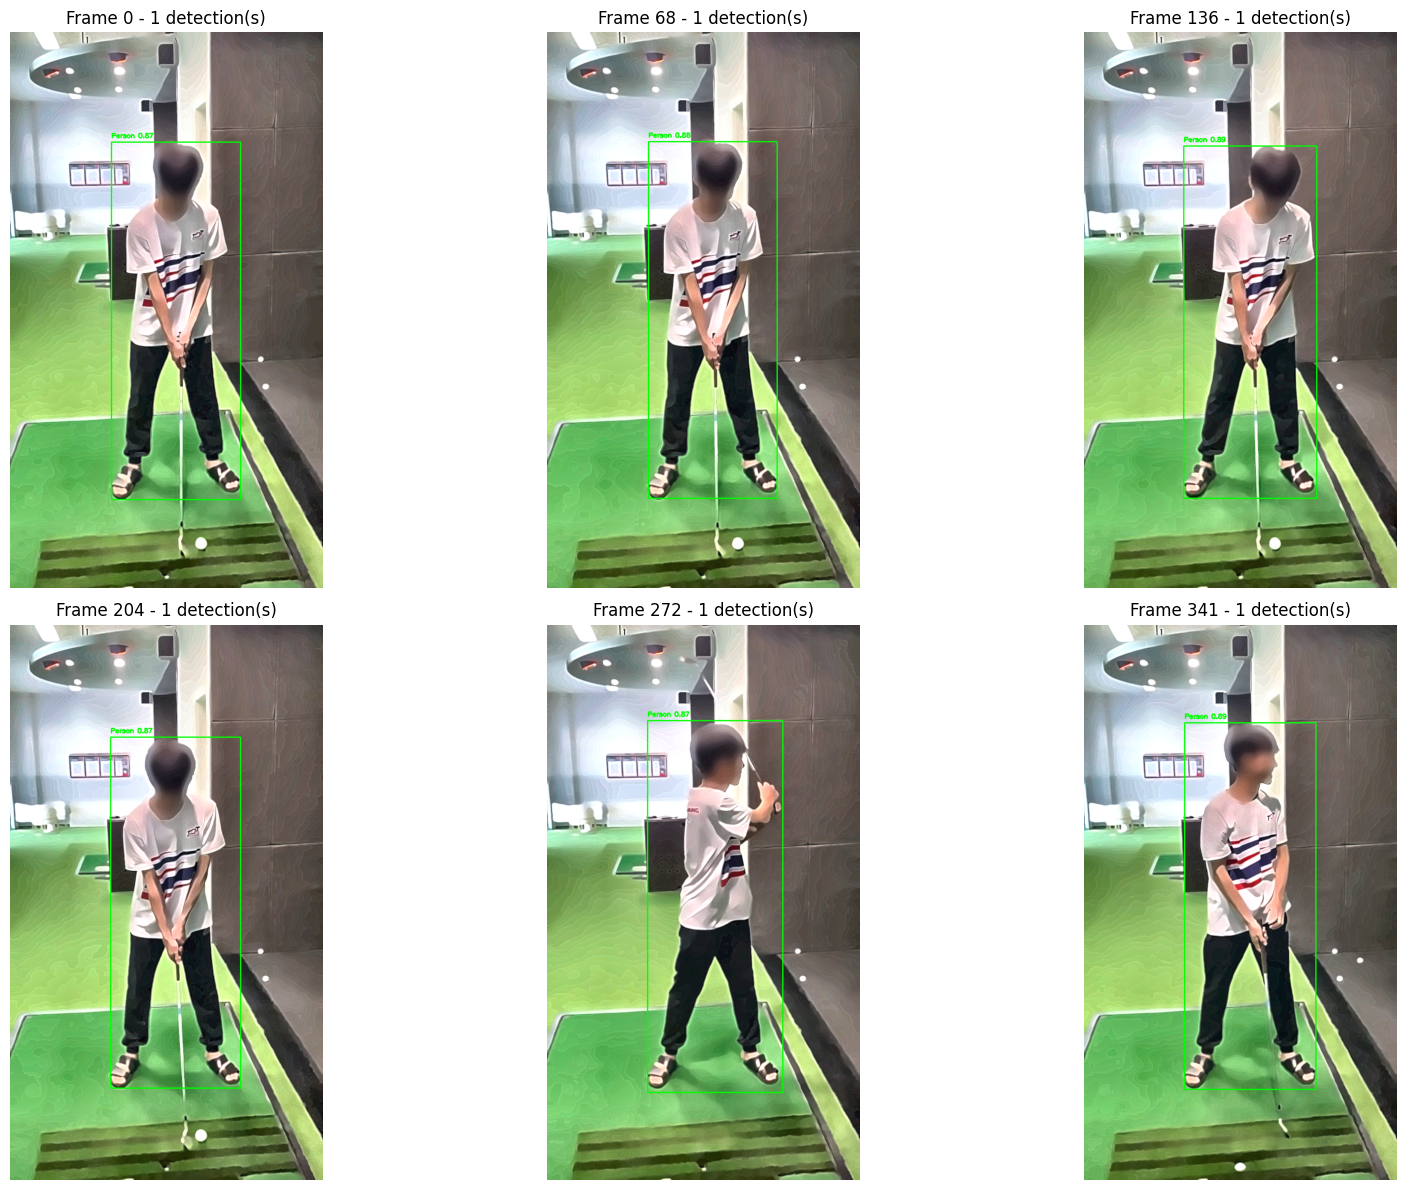

In [ ]:
# Visualize bounding boxes
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

sample_indices = np.linspace(0, len(preprocessed_frames)-1, 6, dtype=int)

for ax, idx in zip(axes, sample_indices):
    frame_copy = preprocessed_frames[idx].copy()
    
    # Draw bounding boxes
    for detection in all_detections[idx]:
        x1, y1, x2, y2 = detection.bbox
        cv2.rectangle(frame_copy, (x1, y1), (x2, y2), (0, 255, 0), 2)
        label = f"Person {detection.confidence:.2f}"
        cv2.putText(frame_copy, label, (x1, y1-10), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    ax.imshow(cv2.cvtColor(frame_copy, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Frame {idx} - {len(all_detections[idx])} detection(s)")
    ax.axis('off')

plt.tight_layout()
plt.show()

## 6. Pose Keypoint Extraction (MediaPipe)

In [ ]:
# Initialize skeleton detector
print("Initializing MediaPipe Pose detector...")
skeleton_detector = SkeletonDetector(
    use_coco_format=DETECTION_CONFIG['use_coco_format']
)
print("✓ Skeleton detector initialized")
print(f"  - Keypoint format: {'COCO (17 keypoints)' if DETECTION_CONFIG['use_coco_format'] else 'Full MediaPipe (33 keypoints)'}")

Initializing MediaPipe Pose detector...
✓ Skeleton detector initialized
  - Keypoint format: COCO (17 keypoints)


In [ ]:
# Extract keypoints from all frames
print("Extracting keypoints from frames...")
all_keypoints = []

for frame_idx, frame in enumerate(tqdm(preprocessed_frames, desc="Extracting keypoints")):
    timestamp_ms = int(frame_idx * 1000 / fps)
    landmarks, pose_landmarks = skeleton_detector.detect_skeleton(frame, timestamp_ms)
    
    if landmarks is not None:
        keypoints_data = {
            'frame_idx': frame_idx,
            'keypoints': landmarks,
            'pose_landmarks': pose_landmarks
        }
        all_keypoints.append(keypoints_data)

print(f"\n✓ Extracted keypoints from {len(all_keypoints)}/{len(preprocessed_frames)} frames")

if len(all_keypoints) == 0:
    print("\n⚠️ WARNING: No keypoints detected!")

Extracting keypoints from frames...


Extracting keypoints:   0%|          | 0/342 [00:00<?, ?it/s]


✓ Extracted keypoints from 342/342 frames


## 7. Export Keypoints to CSV

In [ ]:
if len(all_keypoints) > 0:
    # Convert to DataFrame
    rows = []
    
    for kp_data in all_keypoints:
        frame_idx = kp_data['frame_idx']
        keypoints = kp_data['keypoints']
        
        for kp_name, kp_values in keypoints.items():
            rows.append({
                'frame': frame_idx,
                'keypoint': kp_name,
                'x': kp_values['x'],
                'y': kp_values['y'],
                'visibility': kp_values['visibility']
            })
    
    df_keypoints = pd.DataFrame(rows)
    
    # Save CSV (long format)
    csv_path = OUTPUT_DIR / f"{Path(VIDEO_INPUT).stem}_keypoints.csv"
    df_keypoints.to_csv(csv_path, index=False)
    
    print(f"✓ Keypoints saved to: {csv_path}")
    print(f"  - Total rows: {len(df_keypoints)}")
    print(f"  - Frames: {df_keypoints['frame'].nunique()}")
    print(f"  - Keypoints per frame: {len(df_keypoints) // df_keypoints['frame'].nunique()}")
    
    # Display sample
    print("\nSample data:")
    display(df_keypoints.head(20))
    
    # Save wide format
    df_wide = df_keypoints.pivot_table(
        index='frame',
        columns='keypoint',
        values=['x', 'y', 'visibility']
    )
    
    csv_wide_path = OUTPUT_DIR / f"{Path(VIDEO_INPUT).stem}_keypoints_wide.csv"
    df_wide.to_csv(csv_wide_path)
    
    print(f"\n✓ Wide format saved to: {csv_wide_path}")
    print(f"  Shape: {df_wide.shape}")
else:
    print("⚠️ No keypoints to save!")

✓ Keypoints saved to: pipeline_output\Side-6020-7_keypoints.csv
  - Total rows: 7182
  - Frames: 342
  - Keypoints per frame: 21

Sample data:


,frame,keypoint,x,y,visibility
0,0,nose,397.408748,355.019989,0.992658
1,0,left_eye,408.027978,333.396454,0.977327
2,0,right_eye,383.934188,332.588997,0.990971
3,0,left_ear,415.989633,337.242470,0.991029
4,0,right_ear,360.645189,334.899902,0.991879
5,0,left_shoulder,458.488526,422.887726,0.999954
6,0,right_shoulder,301.664679,436.326675,0.999941
7,0,left_elbow,455.626116,559.420967,0.960271
8,0,right_elbow,329.049926,586.271782,0.989016
9,0,left_wrist,416.867595,676.666107,0.923807


✓ Keypoints saved to: pipeline_output\Side-6020-7_keypoints.csv
  - Total rows: 7182
  - Frames: 342
  - Keypoints per frame: 21

Sample data:


,frame,keypoint,x,y,visibility
0,0,nose,397.408748,355.019989,0.992658
1,0,left_eye,408.027978,333.396454,0.977327
2,0,right_eye,383.934188,332.588997,0.990971
3,0,left_ear,415.989633,337.242470,0.991029
4,0,right_ear,360.645189,334.899902,0.991879
5,0,left_shoulder,458.488526,422.887726,0.999954
6,0,right_shoulder,301.664679,436.326675,0.999941
7,0,left_elbow,455.626116,559.420967,0.960271
8,0,right_elbow,329.049926,586.271782,0.989016
9,0,left_wrist,416.867595,676.666107,0.923807



✓ Wide format saved to: pipeline_output\Side-6020-7_keypoints_wide.csv
  Shape: (342, 63)


## 8. Visualization

### 8.1. Helper Functions

In [ ]:
def draw_skeleton_connections(frame, keypoints_dict):
    """Draw skeleton connections between keypoints."""
    frame_copy = frame.copy()
    
    # Define skeleton connections (BGR format)
    connections = [
        # Face (cyan)
        (('nose', 'left_eye'), (255, 255, 0)),
        (('nose', 'right_eye'), (255, 255, 0)),
        (('left_eye', 'left_ear'), (255, 255, 0)),
        (('right_eye', 'right_ear'), (255, 255, 0)),
        # Torso (green)
        (('left_shoulder', 'right_shoulder'), (0, 255, 0)),
        (('left_shoulder', 'left_hip'), (0, 255, 0)),
        (('right_shoulder', 'right_hip'), (0, 255, 0)),
        (('left_hip', 'right_hip'), (0, 255, 0)),
        # Left arm (blue)
        (('left_shoulder', 'left_elbow'), (255, 0, 0)),
        (('left_elbow', 'left_wrist'), (255, 0, 0)),
        # Right arm (red)
        (('right_shoulder', 'right_elbow'), (0, 0, 255)),
        (('right_elbow', 'right_wrist'), (0, 0, 255)),
        # Left leg (orange)
        (('left_hip', 'left_knee'), (0, 165, 255)),
        (('left_knee', 'left_ankle'), (0, 165, 255)),
        # Right leg (magenta)
        (('right_hip', 'right_knee'), (255, 0, 255)),
        (('right_knee', 'right_ankle'), (255, 0, 255)),
    ]
    
    # Draw connections
    for (kp1_name, kp2_name), color in connections:
        if kp1_name in keypoints_dict and kp2_name in keypoints_dict:
            kp1 = keypoints_dict[kp1_name]
            kp2 = keypoints_dict[kp2_name]
            
            if kp1['visibility'] > 0.3 and kp2['visibility'] > 0.3:
                x1, y1 = int(kp1['x']), int(kp1['y'])
                x2, y2 = int(kp2['x']), int(kp2['y'])
                cv2.line(frame_copy, (x1, y1), (x2, y2), color, 6)
    
    # Draw keypoints
    for kp_name, kp_values in keypoints_dict.items():
        if kp_values['visibility'] > 0.3:
            x = int(kp_values['x'])
            y = int(kp_values['y'])
            cv2.circle(frame_copy, (x, y), 12, (0, 0, 0), -1)  # Black outline
            cv2.circle(frame_copy, (x, y), 10, (0, 255, 255), -1)  # Yellow center
    
    return frame_copy

### 8.2. Visualize Sample Frames

In [ ]:
if len(all_keypoints) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(20, 13))
    axes = axes.flatten()
    
    # Sample 6 frames with keypoints
    sample_kp_indices = np.linspace(0, len(all_keypoints)-1, 6, dtype=int)
    
    for ax, kp_idx in zip(axes, sample_kp_indices):
        kp_data = all_keypoints[kp_idx]
        frame_idx = kp_data['frame_idx']
        frame = preprocessed_frames[frame_idx]
        
        # Draw skeleton
        frame_with_skeleton = draw_skeleton_connections(frame, kp_data['keypoints'])
        
        ax.imshow(cv2.cvtColor(frame_with_skeleton, cv2.COLOR_BGR2RGB))
        ax.set_title(f"Frame {frame_idx} - Skeleton", fontsize=12, fontweight='bold')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("No keypoints to visualize")

Sample frame visualization skipped (processing 342 frames with keypoints)


### 8.3. Create Output Video

In [ ]:
if len(all_keypoints) > 0:
    print("Creating output video with keypoints...")
    
    # Create frame_idx -> keypoints mapping
    keypoints_map = {kp['frame_idx']: kp['keypoints'] for kp in all_keypoints}
    
    # Prepare output video
    output_video_path = OUTPUT_DIR / f"{Path(VIDEO_INPUT).stem}_with_keypoints.mp4"
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    h, w = preprocessed_frames[0].shape[:2]
    video_writer = cv2.VideoWriter(str(output_video_path), fourcc, fps, (w, h))
    
    try:
        for frame_idx, frame in enumerate(tqdm(preprocessed_frames, desc="Writing video")):
            if frame_idx in keypoints_map:
                frame_with_kp = draw_skeleton_connections(frame, keypoints_map[frame_idx])
            else:
                frame_with_kp = frame
            
            # Add frame number
            cv2.putText(frame_with_kp, f"Frame: {frame_idx}", (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)
            
            video_writer.write(frame_with_kp)
    
    finally:
        video_writer.release()
    
    print(f"\n✓ Output video saved to: {output_video_path}")
    print(f"  - Duration: {len(preprocessed_frames)/fps:.2f} seconds")
    print(f"  - FPS: {fps}")
    print(f"  - Resolution: {w}x{h}")
    
    # Display video in notebook
    display(Video(str(output_video_path), width=800))
else:
    print("No keypoints to create video")

Creating output video with keypoints...


Writing video:   0%|          | 0/342 [00:00<?, ?it/s]

NameError: name 'draw_skeleton_connections' is not defined

## 9. Analysis

### 9.1. Keypoint Visibility Statistics

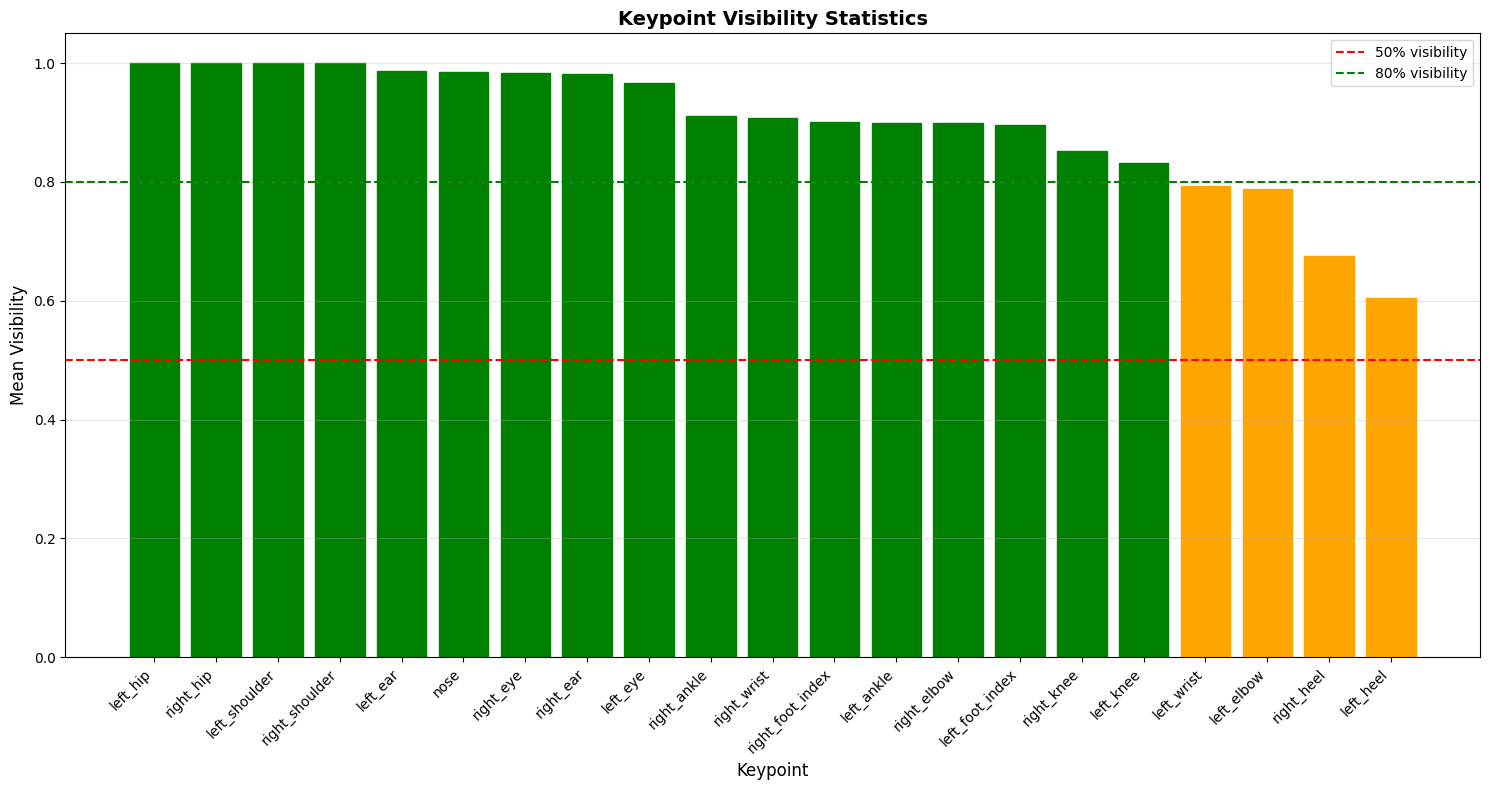


Keypoint Visibility Summary:
  - High visibility (>80%): 17 keypoints
  - Medium visibility (50-80%): 4 keypoints
  - Low visibility (<50%): 0 keypoints


In [ ]:
if len(all_keypoints) > 0:
    # Calculate visibility statistics
    visibility_stats = {}
    
    for kp_data in all_keypoints:
        for kp_name, kp_values in kp_data['keypoints'].items():
            if kp_name not in visibility_stats:
                visibility_stats[kp_name] = []
            visibility_stats[kp_name].append(kp_values['visibility'])
    
    # Calculate mean visibility
    mean_visibility = {k: np.mean(v) for k, v in visibility_stats.items()}
    sorted_kps = sorted(mean_visibility.items(), key=lambda x: x[1], reverse=True)
    
    # Plot
    fig, ax = plt.subplots(figsize=(15, 8))
    
    kp_names = [k for k, v in sorted_kps]
    visibility_values = [v for k, v in sorted_kps]
    
    bars = ax.bar(range(len(kp_names)), visibility_values, edgecolor='navy')
    
    # Color bars based on visibility
    for i, bar in enumerate(bars):
        if visibility_values[i] > 0.8:
            bar.set_color('green')
        elif visibility_values[i] > 0.5:
            bar.set_color('orange')
        else:
            bar.set_color('red')
    
    ax.set_xlabel('Keypoint', fontsize=12)
    ax.set_ylabel('Mean Visibility', fontsize=12)
    ax.set_title('Keypoint Visibility Statistics', fontsize=14, fontweight='bold')
    ax.set_xticks(range(len(kp_names)))
    ax.set_xticklabels(kp_names, rotation=45, ha='right')
    ax.axhline(y=0.5, color='red', linestyle='--', label='50% visibility')
    ax.axhline(y=0.8, color='green', linestyle='--', label='80% visibility')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\nKeypoint Visibility Summary:")
    print(f"  - High visibility (>80%): {sum(1 for v in visibility_values if v > 0.8)} keypoints")
    print(f"  - Medium visibility (50-80%): {sum(1 for v in visibility_values if 0.5 < v <= 0.8)} keypoints")
    print(f"  - Low visibility (<50%): {sum(1 for v in visibility_values if v <= 0.5)} keypoints")

### 9.2. Trajectory Analysis

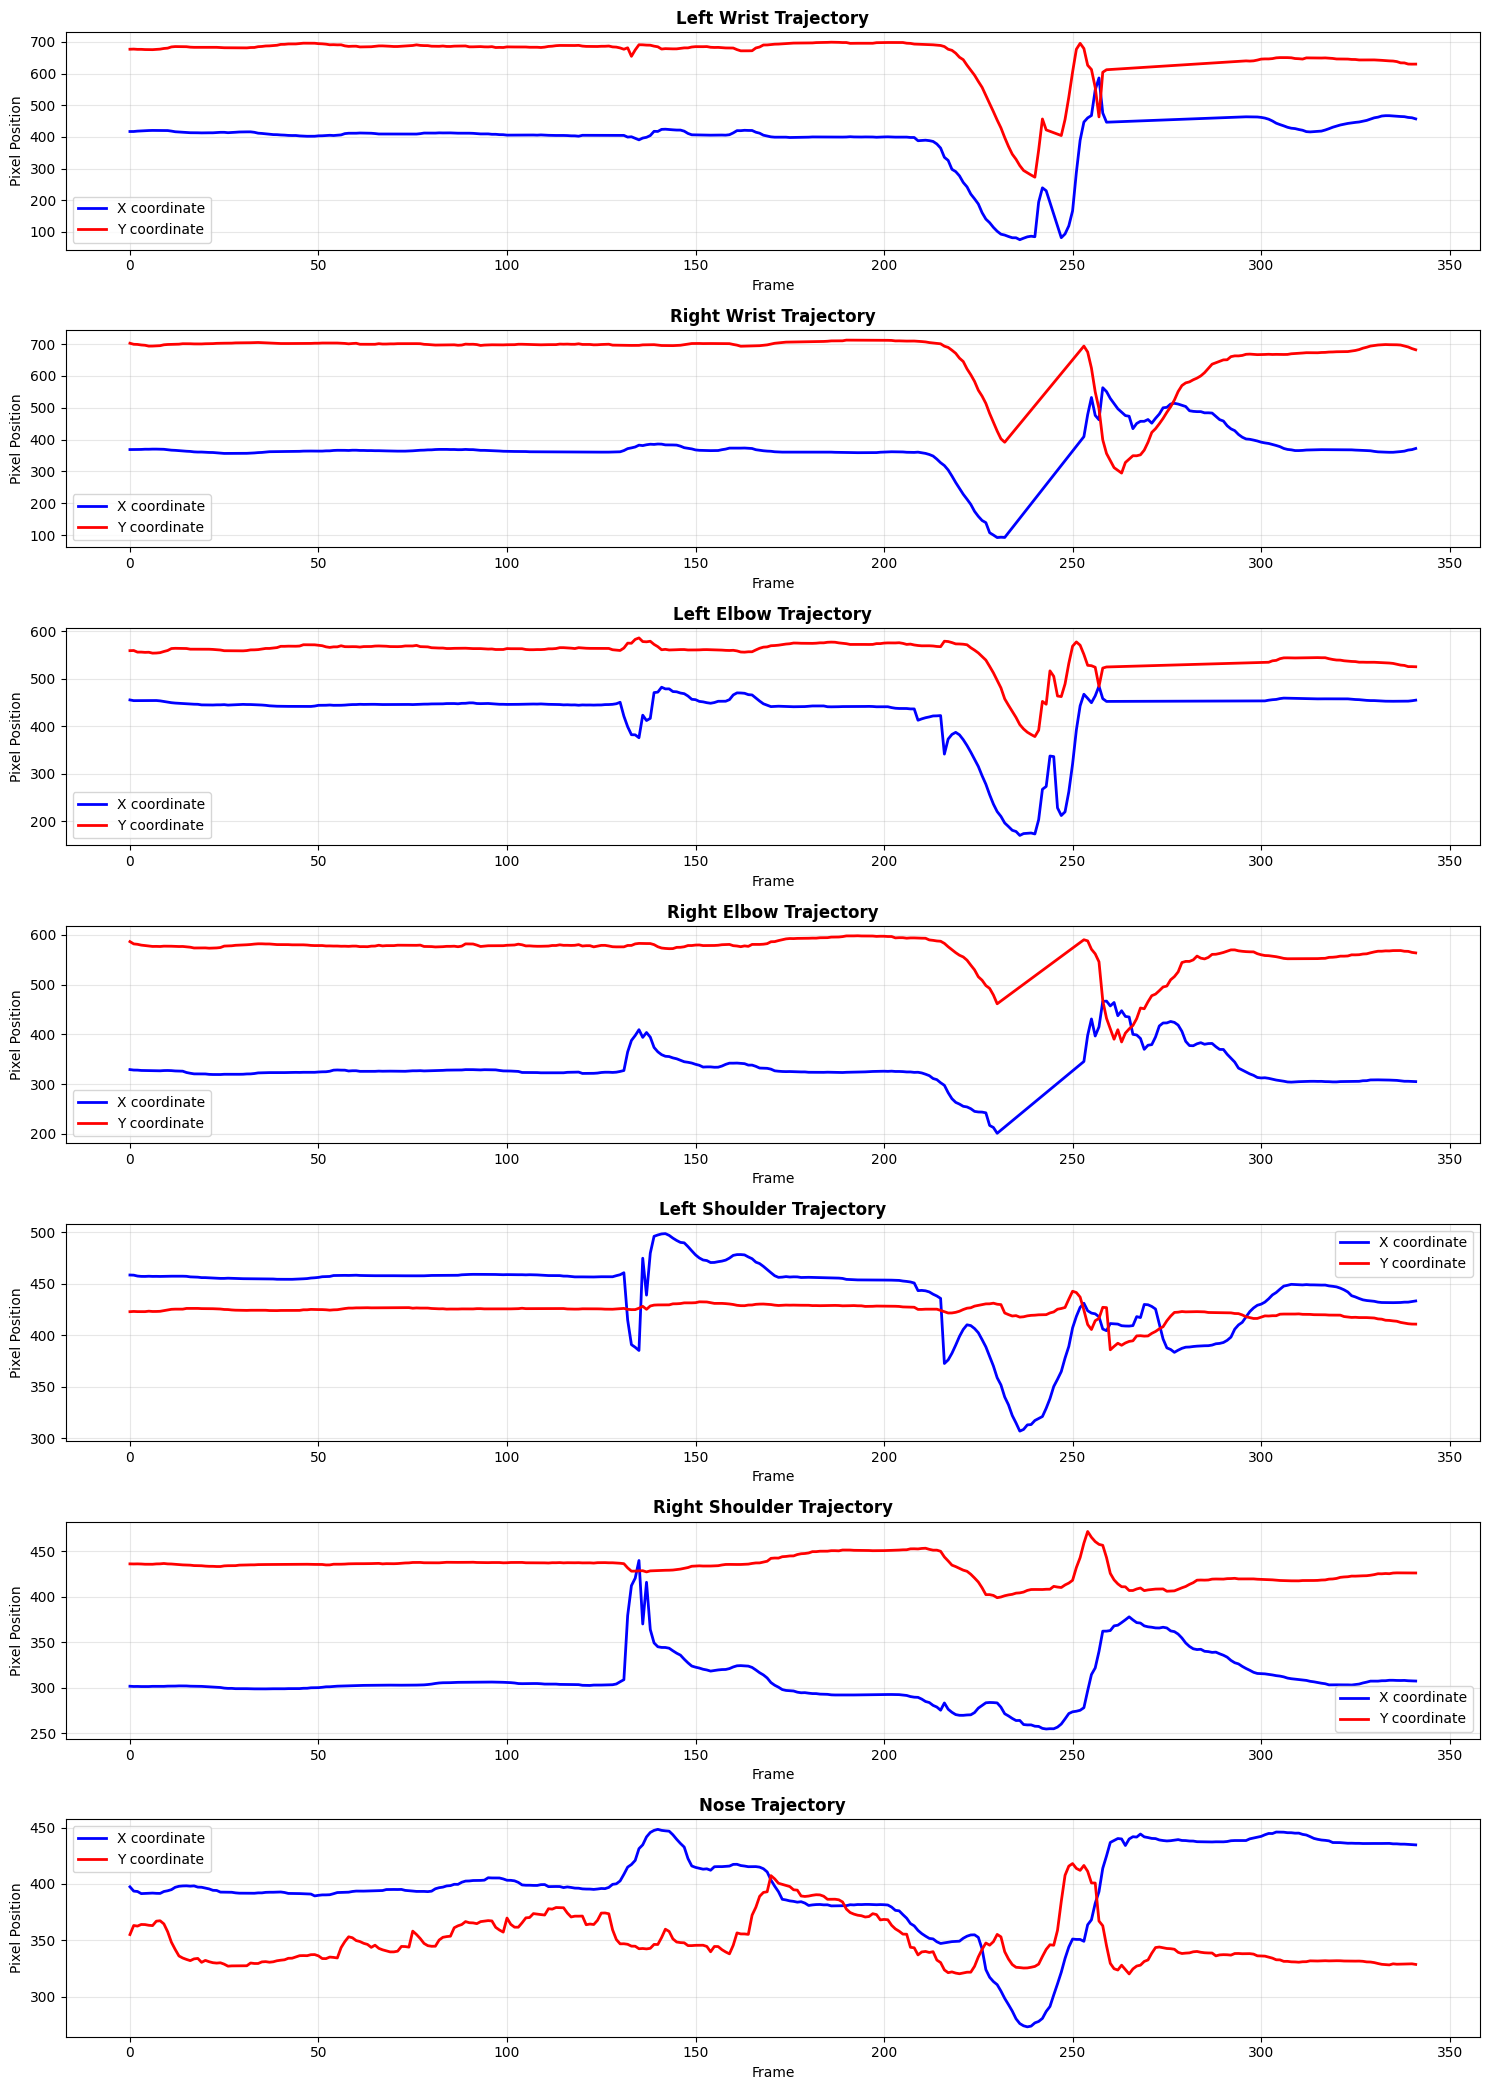

In [ ]:
if len(all_keypoints) > 0:
    # Select important keypoints for trajectory analysis
    important_kps = ['left_wrist', 'right_wrist', 'left_elbow', 'right_elbow', 
                     'left_shoulder', 'right_shoulder', 'nose']
    
    fig, axes = plt.subplots(len(important_kps), 1, figsize=(15, len(important_kps)*3))
    
    for idx, kp_name in enumerate(important_kps):
        frames_list = []
        x_coords = []
        y_coords = []
        
        for kp_data in all_keypoints:
            if kp_name in kp_data['keypoints']:
                kp = kp_data['keypoints'][kp_name]
                if kp['visibility'] > 0.5:
                    frames_list.append(kp_data['frame_idx'])
                    x_coords.append(kp['x'])
                    y_coords.append(kp['y'])
        
        if len(frames_list) > 0:
            ax = axes[idx] if len(important_kps) > 1 else axes
            ax.plot(frames_list, x_coords, 'b-', label='X coordinate', linewidth=2)
            ax.plot(frames_list, y_coords, 'r-', label='Y coordinate', linewidth=2)
            ax.set_xlabel('Frame', fontsize=10)
            ax.set_ylabel('Pixel Position', fontsize=10)
            ax.set_title(f'{kp_name.replace("_", " ").title()} Trajectory', 
                        fontsize=12, fontweight='bold')
            ax.legend()
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 10. Summary Report

In [ ]:
print("="*60)
print("         GOLF POSE ANALYSIS PIPELINE - SUMMARY")
print("="*60)
print(f"\n📹 Input Video: {VIDEO_INPUT}")
print(f"   - Total frames: {len(frames)}")
print(f"   - Duration: {len(frames)/fps:.2f} seconds")
print(f"   - FPS: {fps}")
print(f"   - Resolution: {frames[0].shape[1]}x{frames[0].shape[0]}")

print(f"\n🔧 Preprocessing:")
print(f"   - Method: {'Adaptive' if PREPROCESSING_CONFIG['use_adaptive'] else 'Manual'}")
print(f"   - Sharpening: {'✓' if PREPROCESSING_CONFIG['apply_sharpening'] else '✗'}")
print(f"   - Edge enhancement: {'✓' if PREPROCESSING_CONFIG['apply_edge_enhancement'] else '✗'}")
print(f"   - Denoising: {'✓' if PREPROCESSING_CONFIG['apply_denoise'] else '✗'}")

print(f"\n🎯 Detection:")
print(f"   - Frames with person: {frames_with_detection}/{len(preprocessed_frames)}")
print(f"   - Detection rate: {frames_with_detection/len(preprocessed_frames)*100:.1f}%")

if len(all_keypoints) > 0:
    print(f"\n🦴 Keypoint Extraction:")
    print(f"   - Frames with keypoints: {len(all_keypoints)}/{len(preprocessed_frames)}")
    print(f"   - Success rate: {len(all_keypoints)/len(preprocessed_frames)*100:.1f}%")
    print(f"   - Keypoints per frame: {len(all_keypoints[0]['keypoints'])}")
    print(f"   - Format: {'COCO (17 kps)' if DETECTION_CONFIG['use_coco_format'] else 'MediaPipe (33 kps)'}")
    
    print(f"\n💾 Output Files:")
    print(f"   - CSV (long format): {OUTPUT_DIR / f'{Path(VIDEO_INPUT).stem}_keypoints.csv'}")
    print(f"   - CSV (wide format): {OUTPUT_DIR / f'{Path(VIDEO_INPUT).stem}_keypoints_wide.csv'}")
    print(f"   - Video with keypoints: {OUTPUT_DIR / f'{Path(VIDEO_INPUT).stem}_with_keypoints.mp4'}")
else:
    print(f"\n⚠️ WARNING: No keypoints extracted!")

print("\n" + "="*60)
print("                  PIPELINE COMPLETED")
print("="*60)

         GOLF POSE ANALYSIS PIPELINE - SUMMARY

📹 Input Video: TDTU-Golf-Pose-v1\Public Test\Trong nhà - Indoor\Band 1-2\Side-6020-7.mov
   - Total frames: 342
   - Duration: 11.40 seconds
   - FPS: 30.0
   - Resolution: 720x1280

🔧 Preprocessing:
   - Method: Manual
   - Sharpening: ✗
   - Edge enhancement: ✗
   - Denoising: ✗

🎯 Detection:
   - Frames with person: 342/342
   - Detection rate: 100.0%

🦴 Keypoint Extraction:
   - Frames with keypoints: 342/342
   - Success rate: 100.0%
   - Keypoints per frame: 21
   - Format: MediaPipe (33 kps)

💾 Output Files:
   - CSV (long format): pipeline_output\Side-6020-7_keypoints.csv
   - CSV (wide format): pipeline_output\Side-6020-7_keypoints_wide.csv
   - Video with keypoints: pipeline_output\Side-6020-7_with_keypoints.mp4

                  PIPELINE COMPLETED
